In [1]:
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import os
import pickle
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.models import Model
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
class ImgProcessing:
    def __init__(self):
        pass
        
    def random_erasing(self, img, sl=0.1, sh=0.2, rl=0.4, p=0.4):
        h = tf.shape(img)[0]
        w = tf.shape(img)[1]
        c = tf.shape(img)[2]
        origin_area = tf.cast(h*w, tf.float32)
        e_size_l = tf.cast(tf.round(tf.sqrt(origin_area * sl * rl)), tf.int32)
        e_size_h = tf.cast(tf.round(tf.sqrt(origin_area * sh / rl)), tf.int32)
        e_height_h = tf.minimum(e_size_h, h)
        e_width_h = tf.minimum(e_size_h, w)
        erase_height = tf.random.uniform(shape=[], minval=e_size_l, maxval=e_height_h, dtype=tf.int32)
        erase_width = tf.random.uniform(shape=[], minval=e_size_l, maxval=e_width_h, dtype=tf.int32)
        erase_area = tf.zeros(shape=[erase_height, erase_width, c])
        erase_area = tf.cast(erase_area, tf.uint8)
        pad_h = h - erase_height
        pad_top = tf.random.uniform(shape=[], minval=0, maxval=pad_h, dtype=tf.int32)
        pad_bottom = pad_h - pad_top
        pad_w = w - erase_width
        pad_left = tf.random.uniform(shape=[], minval=0, maxval=pad_w, dtype=tf.int32)
        pad_right = pad_w - pad_left
        erase_mask = tf.pad([erase_area], [[0,0],[pad_top, pad_bottom], [pad_left, pad_right], [0,0]], constant_values=1)
        erase_mask = tf.squeeze(erase_mask, axis=0)
        erased_img = tf.multiply(tf.cast(img,tf.float32), tf.cast(erase_mask, tf.float32))
        return tf.cond(tf.random.uniform([], 0, 1) > p, lambda: tf.cast(img, img.dtype), lambda:  tf.cast(erased_img, img.dtype))

    
    def CLAHE(self, img):
        gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
        clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        return clahe.apply(gray)

In [ ]:
class img_dataset:
    def __init__(self, folder_name, labels, encode_labels_dict):  
        self.folder_name = f'../Dataset/kneeKL224/{folder_name}'
        self.labels = labels
        self.encode_labels_dict = encode_labels_dict
        self.filepath = []
        self.df, self.data_shape, self.label_shape = None, None, None
        self.prepro = ImgProcessing()

    
    def load_dataset(self, grayscale=False, n_data=False):
        data, classes = [], []
        for label in self.labels:
            label_folder = os.path.join(self.folder_name, label)
            img_names = os.listdir(label_folder)# type string (e.g. 'abs12.jpg)            
            for img_name in img_names:
                self.filepath.append(img_name)
                img_path = os.path.join(label_folder, img_name)
                img = cv.imread(img_path)
                img = self.prepro.CLAHE(img)
                data.append(cv.resize(img,(224,224)))                
                classes.append(self.encode_labels_dict[label])
        self.df = pd.DataFrame({"filepath" : self.filepath, "label": classes})
        data = np.array(data)
        data = np.expand_dims(data, axis=-1) 
        data = np.repeat(data, 3, axis=-1)
        classes = np.array(classes)
        self.data_shape = data.shape
        self.label_shape = classes.shape
        return data, classes  
    
    def __str__(self) -> str:
        return f"Image Shape: {self.data_shape}\nLabel Shape: {self.label_shape}\nClasses: {self.labels}"

In [4]:
train = img_dataset(labels=['0', '1', '2', '3', '4'],
                       encode_labels_dict={'0':0, '1':1, '2':2, '3':3, '4':4},
                       folder_name='train',
                       )
X_train, Y_train = train.load_dataset(grayscale=False)

In [5]:
valid = img_dataset(labels=['0', '1', '2', '3', '4'],
                       encode_labels_dict={'0':0, '1':1, '2':2, '3':3, '4':4},
                       folder_name='val',
                       )
X_valid, Y_valid = valid.load_dataset(grayscale=False)

In [6]:
def show_fig(original_img, new_img):
    fig = plt.figure(figsize=(14,14))
    ax1, ax2 = fig.subplots(1,2)
    ax1.imshow(original_img)
    ax2.imshow(new_img)    
    plt.show()

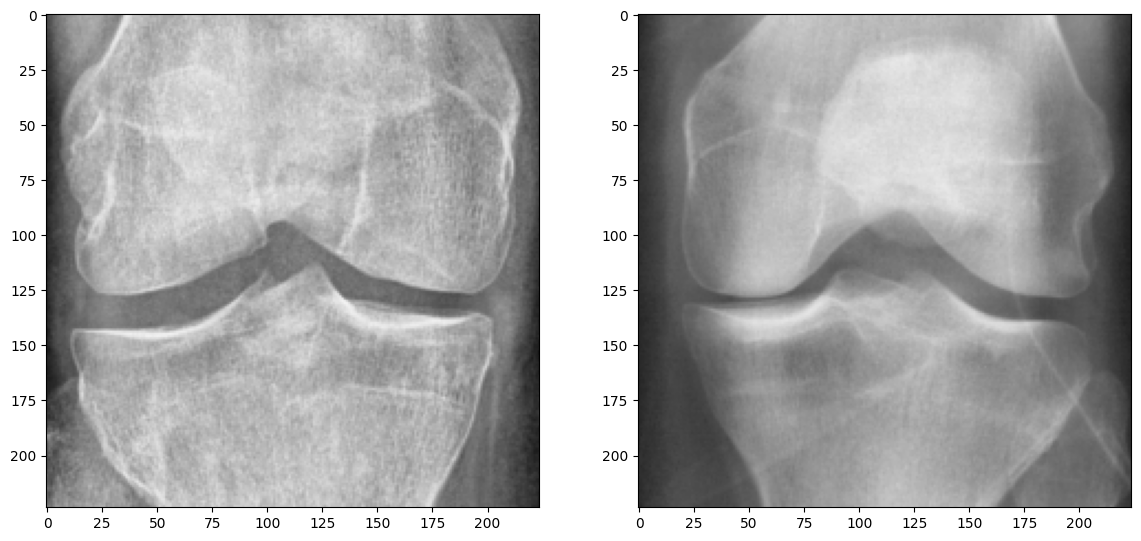

In [8]:
show_fig(X_train[0], X_train[501])

In [9]:
lb = LabelBinarizer()
Y_train = lb.fit_transform(Y_train)
Y_valid = lb.fit_transform(Y_valid)

In [10]:
print('train: ',X_train.shape, Y_train.shape)
print('train: ',X_valid.shape, Y_valid.shape)

train:  (5778, 224, 224, 3) (5778, 5)
train:  (826, 224, 224, 3) (826, 5)


In [11]:
lr = tf.keras.callbacks.ReduceLROnPlateau(
     monitor="val_accuracy",
     factor=0.1,
     patience=5,
     verbose=2,
     mode="max",
     min_delta=0.0001,
     min_lr=0.000001)

In [55]:
checkpoint = ModelCheckpoint(filepath='Best_Ensemble.tf',
                              verbose=2, 
                              save_best_only=True,
                              monitor = 'val_accuracy')

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=7, 
                                              verbose=2, 
                                              restore_best_weights=True)

callbacks = [checkpoint, early_stopping]

In [36]:
img_pro = ImgProcessing()
train_aug = ImageDataGenerator(horizontal_flip=True,
                                vertical_flip=False,
                                shear_range=0.2,rotation_range=25,
                                width_shift_range=0.15,
                                height_shift_range=0.15,
                                zoom_range=0.2,
                               brightness_range=[0.8, 1.2],
                                preprocessing_function = img_pro.random_erasing)

val_aug= ImageDataGenerator()

In [25]:
batch_size=32
train_set = train_aug.flow(X_train,Y_train,
                            batch_size=batch_size, 
                            shuffle= True)
val_set = val_aug.flow(X_valid,Y_valid,
                       batch_size=batch_size, 
                        shuffle= True)

In [ ]:
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Average


model_1 = load_model('../bestmodel/Best_InceptionV3.h5')
model_1 = Model(inputs=model_1.inputs,
               outputs=model_1.outputs,
               name='name_of_model_1')
model_2 = load_model('../bestmodel/Best_Xception.h5')
model_2 = Model(inputs=model_2.inputs,
               outputs=model_2.outputs,
               name='name_of_model_2')
model_3 = load_model('../bestmodel/Best_MobileNetV2.h5')
model_3 = Model(inputs=model_3.inputs,
               outputs=model_3.outputs,
               name='name_of_model_3')
model_4 = load_model('../bestmodel/Best_ResNet101.h5')
model_4 = Model(inputs=model_4.inputs,
               outputs=model_4.outputs,
               name='name_of_model_4')



In [29]:
inputs = Input(shape = (224,224,3))
y_1 = model_1(inputs)
y_2 = model_2(inputs)
y_3 = model_3(inputs)
y_4 = model_4(inputs)

output = Average()([y_1, y_2, y_3, y_4])
ensemble_model = Model(inputs = inputs, outputs = output)
def create_model():
        ensemble_model.compile(optimizer='adam', 
               loss='categorical_crossentropy', 
               metrics=['accuracy'])
        return ensemble_model

ensemble_model = create_model()
ensemble_model.summary()

Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 name_of_model_1 (Functional)   (None, 5)            21813029    ['input_7[0][0]']                
                                                                                                  
 name_of_model_2 (Functional)   (None, 5)            20871725    ['input_7[0][0]']                
                                                                                                  
 name_of_model_3 (Functional)   (None, 5)            2264389     ['input_7[0][0]']          

In [56]:
H = ensemble_model.fit(train_set, 
               steps_per_epoch=5778 // batch_size, 
               validation_data=val_set, 
               validation_steps=826 // batch_size, 
               epochs=120, 
               verbose=2, 
               callbacks = callbacks)

Epoch 1/120

Epoch 1: val_accuracy improved from -inf to 0.37000, saving model to Best_Ensemble.tf
180/180 - 430s - loss: 1.4453 - accuracy: 0.5823 - val_loss: 1.6304 - val_accuracy: 0.3700 - 430s/epoch - 2s/step
Epoch 2/120

Epoch 2: val_accuracy improved from 0.37000 to 0.52000, saving model to Best_Ensemble.tf
180/180 - 419s - loss: 1.4261 - accuracy: 0.5729 - val_loss: 1.6618 - val_accuracy: 0.5200 - 419s/epoch - 2s/step
Epoch 3/120

Epoch 3: val_accuracy improved from 0.52000 to 0.60750, saving model to Best_Ensemble.tf
180/180 - 419s - loss: 1.4200 - accuracy: 0.5747 - val_loss: 1.4239 - val_accuracy: 0.6075 - 419s/epoch - 2s/step
Epoch 4/120

Epoch 4: val_accuracy did not improve from 0.60750
180/180 - 259s - loss: 1.3796 - accuracy: 0.5898 - val_loss: 1.5601 - val_accuracy: 0.5587 - 259s/epoch - 1s/step
Epoch 5/120

Epoch 5: val_accuracy did not improve from 0.60750
180/180 - 261s - loss: 1.4008 - accuracy: 0.5842 - val_loss: 1.4388 - val_accuracy: 0.5587 - 261s/epoch - 1s/step

<function matplotlib.pyplot.show(close=None, block=None)>

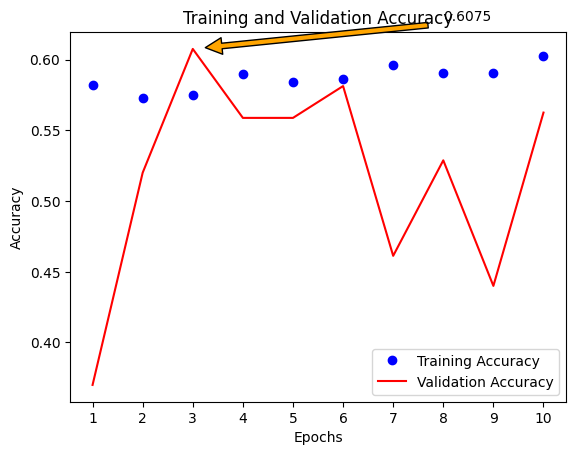

In [57]:
history = ensemble_model.history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label = 'Training Accuracy')
plt.plot(epochs, val_acc, 'r', label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
y_arrow = max(val_acc)
x_arrow = val_acc.index(y_arrow) + 1
plt.annotate(str(y_arrow)[:6],
              (x_arrow, y_arrow),
              xytext=(x_arrow + 5, y_arrow + .02),
              arrowprops=dict(facecolor='orange', shrink=0.05))
plt.xticks(epochs)
plt.show

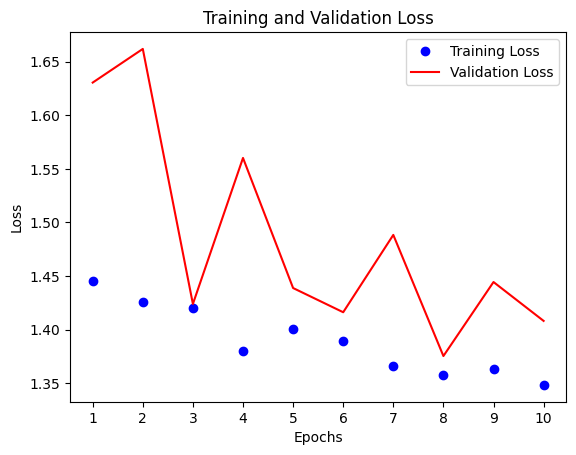

In [58]:
plt.figure()
plt.plot(epochs, loss, 'bo', label = 'Training Loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.xticks(epochs)
plt.show()

In [59]:
test = img_dataset(labels=['0', '1', '2', '3', '4'],
                      encode_labels_dict={'0':0, '1':1, '2':2, '3':3, '4':4},
                      folder_name='test',
                      )
X_test, Y_test = test.load_dataset(grayscale=False)

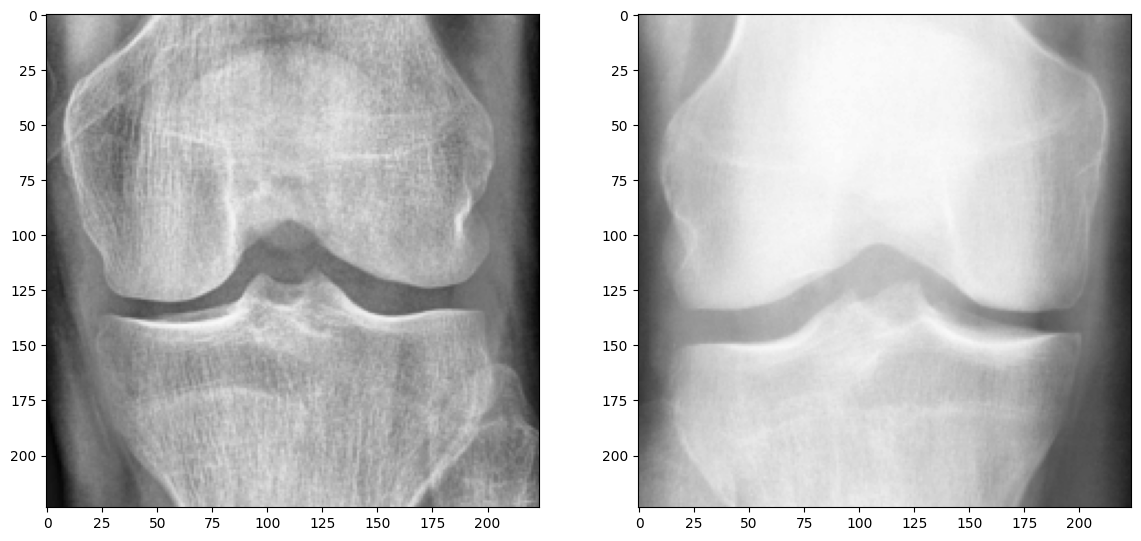

In [60]:
show_fig(X_test[0], X_test[501])

In [61]:
ensemble_model.evaluate(val_set)

26/26 [==============================] - 8s 319ms/step - loss: 1.4301 - accuracy: 0.6029


[1.4301358461380005, 0.6029055714607239]

In [63]:
print(test)
Y_test = lb.fit_transform(Y_test)
print('test: ',X_test.shape, Y_test.shape)
test_aug= ImageDataGenerator()
test_set = test_aug.flow(X_test,Y_test,
                          batch_size=batch_size, 
                          shuffle= False)

Image Shape: (1656, 224, 224, 3)
Label Shape: (1656,)
Classes: ['0', '1', '2', '3', '4']
test:  (1656, 224, 224, 3) (1656, 5)


In [ ]:
save_model = tf.keras.models.load_model("../bestmodel/Best_Ensemble.tf")
save_model.save("./bestmodel/Best_Ensemble.h5")

OSError: No file or directory found at ../kaggle/working/Best_Ensemble.tf

In [ ]:
save_score= save_model.evaluate(X_test, Y_test)
print(save_score)
print('-------------------------------------')

In [ ]:
def encode(array):
    new_array = []
    for i in array:
        index = np.where(i == np.amax(i))[0][0]
        i[index] = int(1)
        for j in range(len(i)):
            if j == index:
                continue
            i[j] = int(0)
        new_array.append(i)
    return new_array

In [ ]:
rs_Ensemble = encode(save_model.predict(X_test).tolist())

In [ ]:
print('Model accuracy Ensemble: ', accuracy_score(rs_Ensemble, Y_test))
print('-------------------------------------')

In [ ]:
print('Ensemble:')
print(classification_report(Y_test, rs_Ensemble))

In [ ]:
from sklearn.metrics import confusion_matrix
import itertools
y_prediction = np.argmax (rs_Ensemble, axis = 1)
y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(y_test, y_prediction)
cm_plot_labels = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Ensemble Model Confusion matrix', 
                          cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)
    
    print(cm)
    
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
        horizontalalignment='center',
        color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('Actual Grade')
    plt.xlabel('Predicted Grade')

In [ ]:
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Ensemble Model Confusion matrix')